# VPINS — AIA Challenge: Feature Engineering — CLONE thử nghiệm (consensus → khử đa cộng tuyến)

> **Clone thử nghiệm.** Khác bản gốc ở **một chỗ**: sau khi có `consensus_rank`, **khử đa cộng
> tuyến NGAY trên ranking** (|corr|>0,9 → giữ feature consensus cao hơn) rồi mới quét `top-K`.
> Mục tiêu: xem lại **biểu đồ perf-vs-K** (`FED08`) trên ranking đã dedupe để **chốt khoảng K**.
> Output ghi ra file `*_dedup` (KHÔNG đụng bản chính). Không tốt thì xoá notebook clone là xong.

Notebook **độc lập** cho feature engineering: tạo đặc trưng nghiệp vụ, phân tích **tương quan & importance đa phương pháp**, **khử đa cộng tuyến**, chọn lọc và **validate bằng grouped OOF (không leakage)**, rồi **bàn giao** sang phần train. Notebook **không** train mô hình cuối / không sinh submission.

**Nguyên tắc:**
- Đặc trưng mới = row-wise, **không dùng target** → tính trên cả train+test. Encoder phụ thuộc target (TargetEncoder/WOE) chỉ fit **trong pipeline theo fold**.
- Mọi quyết định chấm bằng **grouped OOF** (StratifiedGroupKFold theo profile) với **2 mô hình tham chiếu** (LogReg tuyến tính + LightGBM cây). Metric: `mean_hits_over_k` (chính) + `hits@20%` + AUC.

**Bàn giao:** `build_features_v2()` + `load_feature_set()` trong `src/features.py`; `outputs/feature_set_dedup.json` + `outputs/train_fe_dedup.parquet` / `test_fe_dedup.parquet`.

**Mục lục:** 0 Setup · 1 Dữ liệu+đặc trưng · 2 Audit chất lượng · 3 Tạo đặc trưng nghiệp vụ · 4 Tương quan · 5 Khử đa cộng tuyến · 6 Importance · 7 Chọn lọc · 8 Leakage/drift · 9 Bàn giao · 10 Tổng kết

## 0. Setup & evaluation harness

In [1]:
import warnings, os, sys, json, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sys.path.insert(0, os.getcwd())

from src.data import load_data, TARGET, FEATURES, disp, NAME
from src.features import (build_features, build_features_v2, feature_groups_v2,
                          make_preprocessor, encoded_layout, cluster_representatives,
                          vif_prune, WOEEncoder, frequency_encode, INS_DOMAINS)
from src.cv import profile_groups, oof_proba
from src.models import get_models
from src.metrics import summarize, mean_hits_over_k
from sklearn.linear_model import LogisticRegression

plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)
def savefig(n): plt.savefig(FIG / (n + ".png"), dpi=150, bbox_inches="tight")

FE_REPEATS = 2     # repeats CV cho mỗi lần đánh giá (notebook FE -> nhẹ)
SEED = 42
print("FE_REPEATS =", FE_REPEATS)

FE_REPEATS = 2


In [2]:
# Harness: chấm 1 bộ đặc trưng bằng grouped OOF với 2 mô hình tham chiếu
train, test = load_data()
Xtr, Xte, ENG = build_features_v2(train, test)
y = train[TARGET].astype(int); pos_rate = y.mean()
GROUPS = profile_groups(Xtr)
RAW = list(FEATURES)
ENG = list(ENG)
FULL = RAW + ENG
print(f"Train {Xtr.shape} | Test {Xte.shape} | dương {pos_rate:.4f} | #profiles {len(np.unique(GROUPS))}")
print(f"RAW={len(RAW)} | ENG(v2)={len(ENG)} | FULL={len(FULL)}")

REF = {
    "LogReg":   {"est": LogisticRegression(max_iter=2000, class_weight="balanced"), "scale": True, "te": True},
    "LightGBM": get_models(pos_rate)["LightGBM"],
}
def eval_set(cols, n_repeats=FE_REPEATS):
    """grouped OOF cho 2 mô hình tham chiếu -> DataFrame (model x metric)."""
    rows = []
    for nm, sp in REF.items():
        o, _ = oof_proba(sp, Xtr, y, cols, n_repeats=n_repeats, groups=GROUPS)
        s = {"model": nm, "n_cột": len(cols), "AUC": summarize(y, o)["AUC"],
             "hits@20%": summarize(y, o)["hits@20%"], "meanK": mean_hits_over_k(y, o)}
        rows.append(s)
    return pd.DataFrame(rows).set_index("model")

def eval_compact(cols):
    """Trả (meanK_trung_bình_2model, hits_LightGBM, AUC_trung_bình) để xếp hạng bộ."""
    d = eval_set(cols)
    return float(d["meanK"].mean()), int(d.loc["LightGBM", "hits@20%"]), float(d["AUC"].mean())
print("Harness sẵn sàng.")

Train (5822, 127) | Test (4000, 126) | dương 0.0598 | #profiles 5171
RAW=85 | ENG(v2)=40 | FULL=125
Harness sẵn sàng.


## 1. Dữ liệu + đặc trưng hiện có — mốc baseline

`build_features_v2` đã tạo toàn bộ đặc trưng nghiệp vụ. Ghi **mốc** grouped OOF cho `raw (85)`, `eng (v1)` và `full (v2)` để so sánh xuyên suốt.

In [3]:
from src.features import build_features as _bf
_, _, ENG1 = _bf(train, test)   # đặc trưng v1 (aggregates + flags gốc)
ENG1 = list(ENG1)
sets0 = {"raw (85)": RAW, "eng v1": RAW + ENG1, "full v2": FULL}
base_rows = []
for nm, cs in sets0.items():
    d = eval_set(cs); d["bộ"] = nm; base_rows.append(d.reset_index())
base0 = pd.concat(base_rows).set_index(["bộ", "model"])
print(base0.round(4))
print("\nNhóm đặc trưng v2:", {k: len(v) for k, v in feature_groups_v2(ENG).items()})

                   n_cột     AUC  hits@20%  meanK
bộ       model                                   
raw (85) LogReg       85  0.7345       165  163.2
         LightGBM     85  0.7347       163  163.2
eng v1   LogReg       98  0.7411       172  171.2
         LightGBM     98  0.7458       169  166.8
full v2  LogReg      125  0.7588       181  177.6
         LightGBM    125  0.7432       164  164.2

Nhóm đặc trưng v2: {'Đóng phí lĩnh vực': 6, 'Số loại lĩnh vực': 6, 'Tỉ lệ': 4, 'Chỉ số socio': 5, 'Tương tác': 4, 'Cờ (flag)': 8, 'Tổng hợp gốc': 5, 'Frequency-encode': 2}


## 2. Audit chất lượng đặc trưng (đơn biến)

Cardinality, **near-zero variance** (tỉ lệ giá trị trội), **zero-inflation %**. Gắn cờ biến hằng/gần hằng để cân nhắc loại.

Biến near-zero-variance (>=99% một giá trị): 20
                     feature  dom_value_%  zero_%
   Đóng phí BH ván lướt sóng         99.9    99.9
      Số HĐ BH ván lướt sóng         99.9    99.9
         Số HĐ BH xe tải lớn         99.8    99.8
      Đóng phí BH xe tải lớn         99.8    99.8
    Số HĐ BH máy nông nghiệp         99.6    99.6
 Đóng phí BH máy nông nghiệp         99.6    99.6
      Đóng phí BH khuyết tật         99.6    99.6
         Số HĐ BH khuyết tật         99.6    99.6
 Đóng phí BH tai nạn cá nhân         99.5    99.5
    Số HĐ BH tai nạn cá nhân         99.5    99.5
             Số HĐ BH thuyền         99.4    99.4
                Có BH thuyền         99.4    99.4
          Đóng phí BH thuyền         99.4    99.4
   Số HĐ BH tai nạn gia đình         99.3    99.3
Đóng phí BH tai nạn gia đình         99.3    99.3


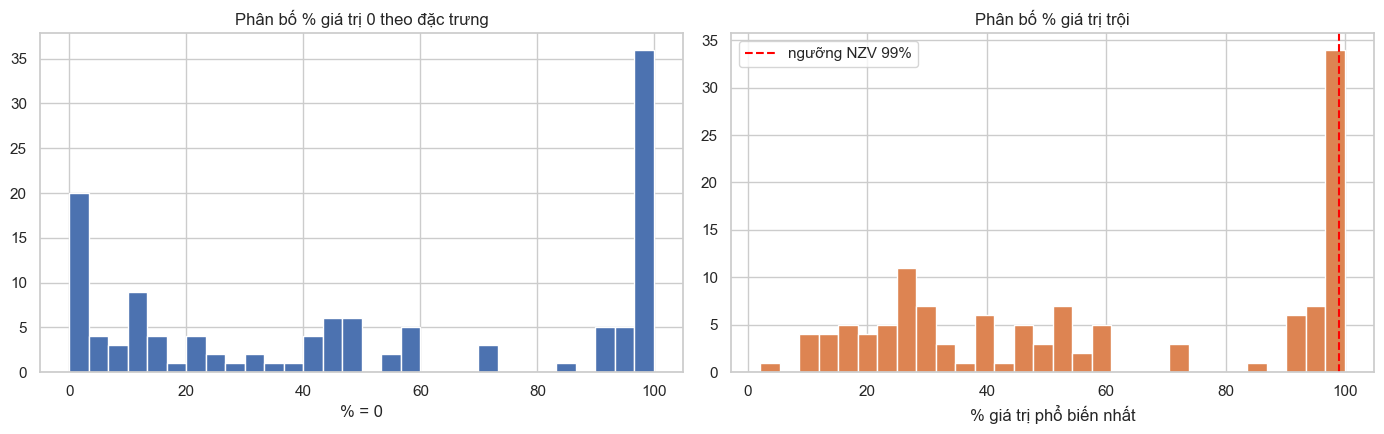

In [4]:
rows = []
for c in FULL:
    s = Xtr[c]
    vc = s.value_counts(normalize=True)
    rows.append({"feature": disp(c), "col": c, "nunique": s.nunique(),
                 "dom_value_%": round(vc.iloc[0]*100, 1), "zero_%": round((s == 0).mean()*100, 1),
                 "std": round(s.std(), 3)})
audit = pd.DataFrame(rows)
nzv = audit[audit["dom_value_%"] >= 99].sort_values("dom_value_%", ascending=False)
print(f"Biến near-zero-variance (>=99% một giá trị): {len(nzv)}")
print(nzv[["feature", "dom_value_%", "zero_%"]].head(15).to_string(index=False))
NZV_COLS = nzv["col"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(audit["zero_%"], bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Phân bố % giá trị 0 theo đặc trưng"); axes[0].set_xlabel("% = 0")
axes[1].hist(audit["dom_value_%"], bins=30, color="#dd8452", edgecolor="white")
axes[1].axvline(99, color="red", ls="--", label="ngưỡng NZV 99%")
axes[1].set_title("Phân bố % giá trị trội"); axes[1].set_xlabel("% giá trị phổ biến nhất"); axes[1].legend()
plt.tight_layout(); savefig("FED01_quality_audit"); plt.show()

## 3. Đặc trưng nghiệp vụ + so sánh encoding cho biến cardinal cao

Liệt kê đặc trưng v2 theo nhóm; so 3 cách mã hoá cho subtype/main type (cột 1 & 5): **TargetEncoder** (CV-safe) vs **WOE** (CV-safe) vs **frequency** (target-free) — chấm bằng grouped OOF.

In [5]:
groups_v2 = feature_groups_v2(ENG)
for g, cs in groups_v2.items():
    print(f"[{g}] ({len(cs)}): {[disp(c) for c in cs]}")

# MI nhanh của đặc trưng v2 với target (chỉ để xem, dùng encoded đúng thứ tự)
from sklearn.feature_selection import mutual_info_classif
ordered, dmask = encoded_layout(FULL)
Xenc = make_preprocessor(FULL, scale=False).fit_transform(Xtr, y)
MI = pd.Series(mutual_info_classif(Xenc, y, discrete_features=dmask, random_state=SEED), index=ordered)
top_new = MI[[c for c in ENG if c in MI.index]].sort_values(ascending=False).head(12)
print("\nTop đặc trưng v2 theo MI:")
print(top_new.rename(index=lambda c: disp(c)).round(4).to_string())

[Đóng phí lĩnh vực] (6): ['Tổng phí BH xe cộ', 'Tổng phí BH nông nghiệp', 'Tổng phí BH nhà/tài sản', 'Tổng phí BH nhân thọ-sức khoẻ', 'Tổng phí BH giải trí', 'Tổng phí BH trách nhiệm']
[Số loại lĩnh vực] (6): ['Số loại BH xe cộ', 'Số loại BH nông nghiệp', 'Số loại BH nhà/tài sản', 'Số loại BH nhân thọ-sức khoẻ', 'Số loại BH giải trí', 'Số loại BH trách nhiệm']
[Tỉ lệ] (4): ['Tỉ trọng phí BH xe', 'Tỉ trọng phí BH nhân thọ-SK', 'Phí/HĐ trung bình', 'Cân bằng #loại số HĐ/đóng phí']
[Chỉ số socio] (5): ['Chỉ số mức thu nhập', 'Chỉ số sung túc (affluence)', 'Chỉ số học vấn', 'Chỉ số gia đình', 'Chỉ số tôn giáo']
[Tương tác] (4): ['Sức mua × có BH xe', 'Thu nhập × sức mua', 'Sung túc × đã có BH', 'Tuổi × nhóm KH chính']
[Cờ (flag)] (8): ['Có BH ô tô', 'Có BH cháy nổ', 'Có BH nhân thọ', 'Có BH tài sản', 'Có BH trách nhiệm cá nhân', 'Có BH thuyền', 'Có HĐ ô tô (≥1)', 'Sở hữu ≥3 loại BH']
[Tổng hợp gốc] (5): ['Tổng mức đóng phí BH khác', 'Tổng số HĐ BH khác', 'Số loại BH có đóng phí', 'Số loại 


Top đặc trưng v2 theo MI:
Tỉ trọng phí BH xe               0.0314
Phí/HĐ trung bình                0.0310
Sung túc × đã có BH              0.0237
Chỉ số sung túc (affluence)      0.0236
Tổng mức đóng phí BH khác        0.0213
Tổng phí BH xe cộ                0.0175
Mức BH liên quan xe              0.0158
Sức mua × có BH xe               0.0155
Số loại BH đang sở hữu           0.0123
Số loại BH có đóng phí           0.0123
Cân bằng #loại số HĐ/đóng phí    0.0123
Tổng số HĐ BH khác               0.0122


In [6]:
# So encoding cho HICARD = ['1','5']
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, StandardScaler
from src.data import HICARD
rest = [c for c in FULL if c not in HICARD]
def enc_pipe(kind):
    if kind == "target":
        enc = ("te", TargetEncoder(target_type="binary", random_state=SEED), HICARD)
    elif kind == "woe":
        enc = ("woe", WOEEncoder(), HICARD)
    else:  # frequency: dùng cột freq_* đã có, bỏ cột gốc HICARD
        return None
    ct = ColumnTransformer([enc, ("pass", "passthrough", rest)])
    return ct
res_enc = []
for kind in ["target", "woe", "frequency"]:
    if kind == "frequency":
        cols = [c for c in FULL if c not in HICARD]   # thay bằng freq_1, freq_5 đã có sẵn
        sp = {"est": get_models(pos_rate)["LightGBM"]["est"], "scale": False, "te": False}
        o, _ = oof_proba(sp, Xtr, y, cols, n_repeats=FE_REPEATS, groups=GROUPS)
    else:
        ct = enc_pipe(kind)
        pipe = Pipeline([("ct", ct), ("clf", get_models(pos_rate)["LightGBM"]["est"].__class__(**get_models(pos_rate)["LightGBM"]["est"].get_params()))])
        from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
        o = np.zeros(len(y))
        for r in range(FE_REPEATS):
            cv = StratifiedGroupKFold(5, shuffle=True, random_state=SEED+r)
            o += cross_val_predict(pipe, Xtr[FULL], y, cv=cv, method="predict_proba", groups=GROUPS, n_jobs=1)[:, 1]
        o /= FE_REPEATS
    res_enc.append({"encoding": kind, "hits@20%": summarize(y, o)["hits@20%"], "meanK": round(mean_hits_over_k(y, o), 1), "AUC": round(summarize(y, o)["AUC"], 4)})
print(pd.DataFrame(res_enc).set_index("encoding"))

           hits@20%  meanK     AUC
encoding                          
target          164  164.2  0.7432
woe             159  159.8  0.7438
frequency       163  162.4  0.7449


## 4. Tương quan đa phương pháp

Spearman + Pearson (ordinal); **Cramér's V** (categorical–categorical); với target: point-biserial + Spearman + mutual information. Heatmap + clustermap; liệt kê cụm |corr|>0,9.

Top 20 đặc trưng liên quan target (3 phương pháp):
                               spearman  point_biserial      MI
Tỉ trọng phí BH xe               0.0438          0.0327  0.0314
Phí/HĐ trung bình                0.0596          0.0371  0.0310
Sung túc × đã có BH              0.0896          0.0857  0.0237
Chỉ số sung túc (affluence)      0.1008          0.1032  0.0236
Tổng mức đóng phí BH khác        0.1622          0.1537  0.0213
Tổng phí BH xe cộ                0.1471          0.1290  0.0175
Đóng phí BH ô tô                 0.1637          0.1509  0.0167
Mức BH liên quan xe              0.1561          0.1399  0.0158
Sức mua × có BH xe               0.1718          0.1784  0.0155
Số loại BH có đóng phí           0.1363          0.1384  0.0123
Số loại BH đang sở hữu           0.1363          0.1384  0.0123
Cân bằng #loại số HĐ/đóng phí    0.1363          0.0146  0.0123
Tổng số HĐ BH khác               0.1355          0.1327  0.0122
Đóng phí BH cháy nổ              0.1005          0.09

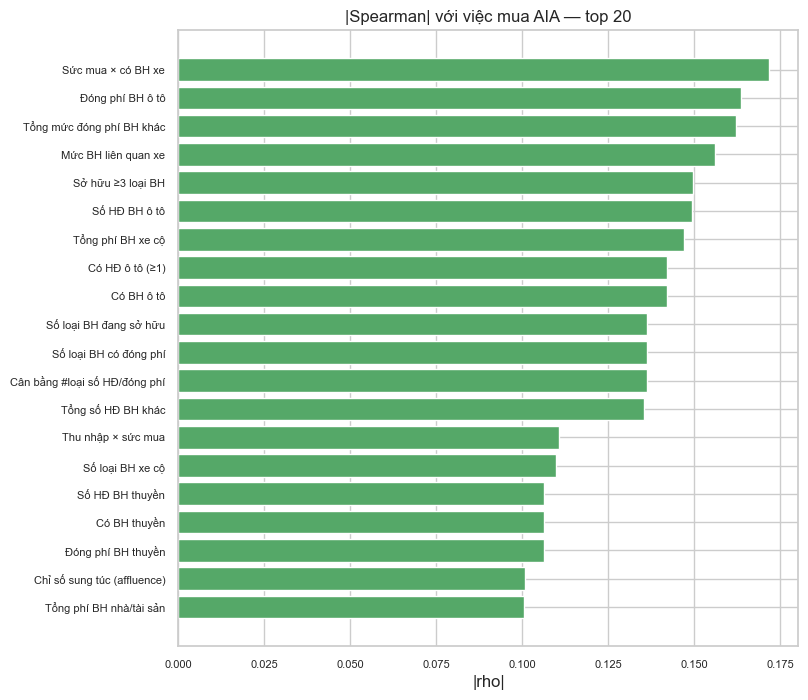

In [7]:
from scipy.stats import spearmanr, pointbiserialr
# Tương quan với target (3 cách)
corr_tbl = pd.DataFrame(index=FULL)
corr_tbl["spearman"] = [spearmanr(Xtr[c], y).statistic for c in FULL]
corr_tbl["point_biserial"] = [pointbiserialr(y, Xtr[c]).statistic for c in FULL]
corr_tbl["MI"] = [MI.get(c, np.nan) for c in FULL]
corr_tbl.index = [disp(c) for c in FULL]
top = corr_tbl.reindex(corr_tbl["MI"].sort_values(ascending=False).index).head(20)
print("Top 20 đặc trưng liên quan target (3 phương pháp):")
print(top.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 8))
t = corr_tbl["spearman"].abs().sort_values(ascending=False).head(20)[::-1]
ax.barh(t.index, t.values, color="#55a868")
ax.set_title("|Spearman| với việc mua AIA — top 20"); ax.set_xlabel("|rho|"); ax.tick_params(labelsize=8)
savefig("FED02_corr_with_target"); plt.show()

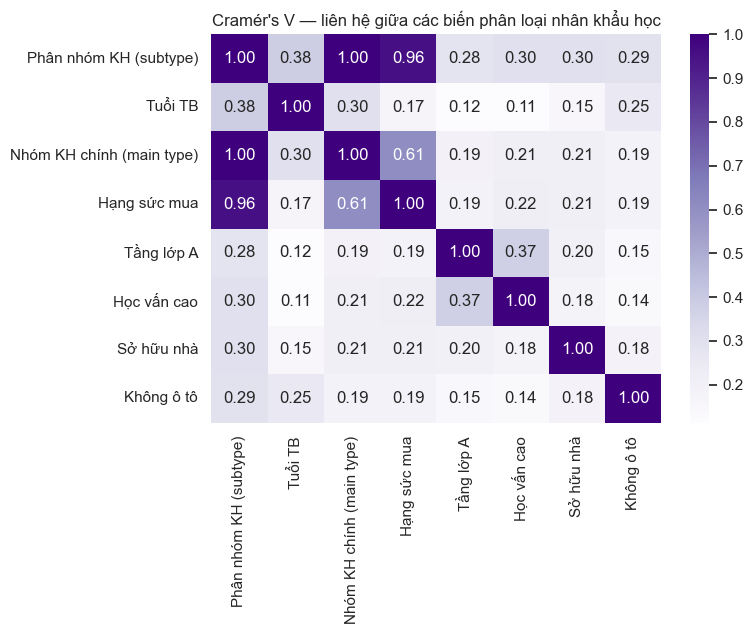

In [8]:
# Cramér's V giữa vài biến categorical chính
from scipy.stats import chi2_contingency
def cramers_v(a, b):
    ct = pd.crosstab(a, b); chi2 = chi2_contingency(ct)[0]; n = ct.values.sum()
    r, k = ct.shape
    return np.sqrt((chi2/n) / max(1, min(r-1, k-1)))
cat_cols = ["1", "4", "5", "43", "25", "16", "31", "34"]
cv_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for a in cat_cols:
    for b in cat_cols:
        cv_mat.loc[a, b] = cramers_v(Xtr[a], Xtr[b])
cv_mat.index = [disp(c) for c in cat_cols]; cv_mat.columns = [disp(c) for c in cat_cols]
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cv_mat.astype(float), annot=True, fmt=".2f", cmap="Purples", ax=ax)
ax.set_title("Cramér's V — liên hệ giữa các biến phân loại nhân khẩu học")
plt.tight_layout(); savefig("FED03_cramers_v"); plt.show()

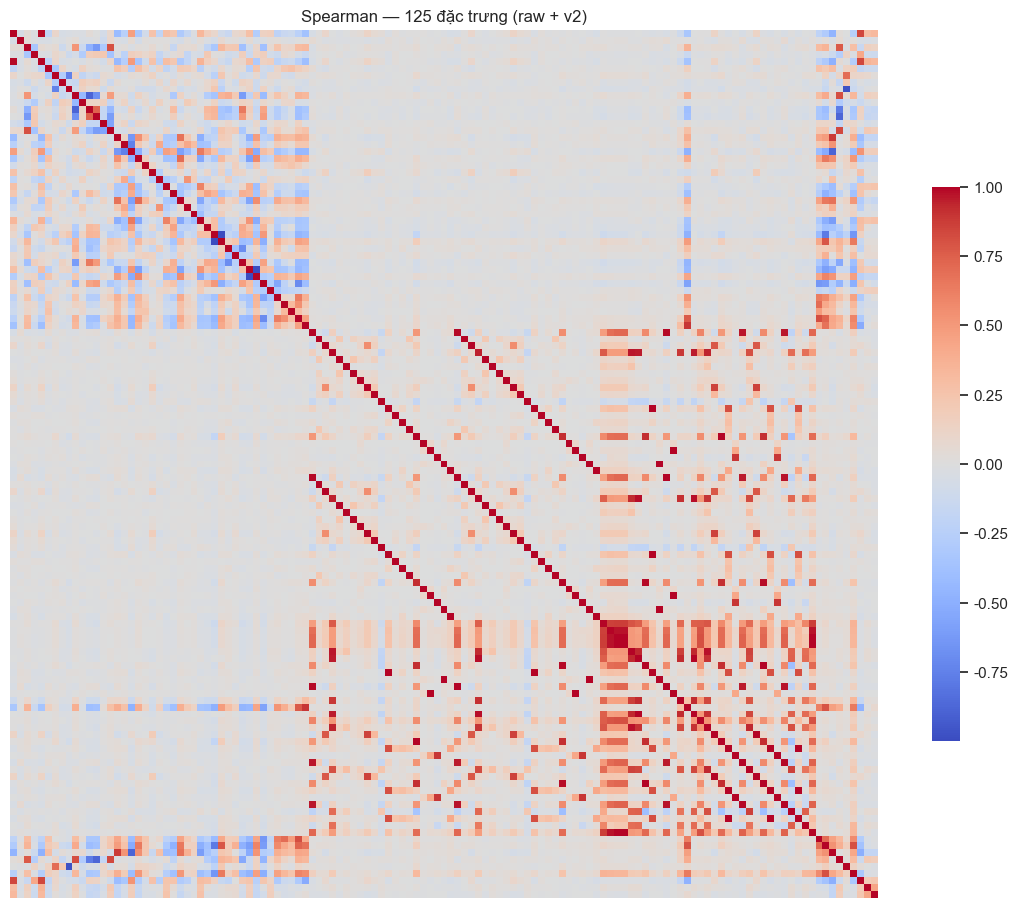

Số cụm |corr|>0.9 có >1 thành viên: 29 (gộp giảm 45 cột)
  giữ [Đóng phí BH thuyền]  <-  ['Đóng phí BH thuyền', 'Số HĐ BH thuyền', 'Có BH thuyền']
  giữ [Số HĐ BH xe đạp]  <-  ['Đóng phí BH xe đạp', 'Số HĐ BH xe đạp']
  giữ [Tổng phí BH giải trí]  <-  ['Tổng phí BH giải trí', 'Số loại BH giải trí']
  giữ [Đóng phí BH ván lướt sóng]  <-  ['Đóng phí BH ván lướt sóng', 'Số HĐ BH ván lướt sóng']
  giữ [Đóng phí BH tài sản]  <-  ['Đóng phí BH tài sản', 'Số HĐ BH tài sản', 'Có BH tài sản']
  giữ [Chỉ số tôn giáo]  <-  ['Không tôn giáo', 'Chỉ số tôn giáo']
  giữ [Nhóm KH chính (main type)]  <-  ['Phân nhóm KH (subtype)', 'Nhóm KH chính (main type)']
  giữ [Nhà thuê]  <-  ['Nhà thuê', 'Sở hữu nhà']
  giữ [BHYT quốc gia]  <-  ['BHYT quốc gia', 'BHYT tư nhân']
  giữ [Đóng phí BH tai nạn cá nhân]  <-  ['Đóng phí BH tai nạn cá nhân', 'Số HĐ BH tai nạn cá nhân']
  giữ [Đóng phí BH mô tô/scooter]  <-  ['Đóng phí BH mô tô/scooter', 'Số HĐ BH mô tô/scooter']
  giữ [Đóng phí BH tai nạn gia đình]  <-  [

In [9]:
# Heatmap Spearman + clustermap; liệt kê cụm |corr|>0.9
corr = Xtr[FULL].corr(method="spearman")
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, xticklabels=False, yticklabels=False,
            cbar_kws={"shrink": .6}, ax=ax)
ax.set_title(f"Spearman — {len(FULL)} đặc trưng (raw + v2)")
savefig("FED04_corr_heatmap"); plt.show()

# cụm tương quan cao
score_mi = {c: MI.get(c, 0.0) for c in FULL}
kept_corr, clusters = cluster_representatives(Xtr, FULL, score_mi, threshold=0.90)
multi = {r: m for r, m in clusters.items() if len(m) > 1}
print(f"Số cụm |corr|>0.9 có >1 thành viên: {len(multi)} (gộp giảm {len(FULL)-len(kept_corr)} cột)")
for r, m in list(multi.items())[:12]:
    print(f"  giữ [{disp(r)}]  <-  {[disp(x) for x in m]}")

## 5. Khử đa cộng tuyến

(a) Gom cụm theo |corr|>0,9 giữ đại diện (MI cao nhất). (b) VIF lặp cho khối tuyến tính. So grouped OOF trước/sau để chắc không tụt.

In [10]:
AFTER_MC = kept_corr   # sau gom cụm tương quan
# VIF chỉ chạy trên các đặc trưng liên tục/chỉ số (khối dễ đa cộng tuyến tuyến tính)
cont_like = [c for c in AFTER_MC if c.startswith(("idx_", "ratio_", "dom_", "agg_", "freq_")) or c in ["42", "43"]]
kept_vif, removed_vif = vif_prune(Xtr, cont_like, thresh=10.0)
AFTER_VIF = [c for c in AFTER_MC if c not in cont_like] + kept_vif
print(f"FULL={len(FULL)} -> sau gom cụm corr={len(AFTER_MC)} -> sau VIF={len(AFTER_VIF)}")
print("VIF loại:", [(disp(c), round(v, 1)) for c, v in removed_vif][:10])

cmp = []
for nm, cs in {"full v2": FULL, "after corr-cluster": AFTER_MC, "after VIF": AFTER_VIF}.items():
    mK, hL, auc = eval_compact(cs); cmp.append({"bộ": nm, "n_cột": len(cs), "meanK(2mdl)": round(mK,1), "hits_LGB": hL, "AUC": round(auc,4)})
print(); print(pd.DataFrame(cmp).set_index("bộ"))

FULL=125 -> sau gom cụm corr=80 -> sau VIF=78
VIF loại: [('Tổng mức đóng phí BH khác', 29.0), ('Số loại BH xe cộ', 24.0)]



                    n_cột  meanK(2mdl)  hits_LGB     AUC
bộ                                                      
full v2               125        170.9       164  0.7510
after corr-cluster     80        169.2       161  0.7498
after VIF              78        165.6       156  0.7494


## 6. Importance đa phương pháp → xếp hạng đồng thuận

Filter (MI, ANOVA F, point-biserial) + embedded (L1-logistic, LightGBM gain) + permutation (grouped) + SHAP. Gộp thành **consensus rank** (trung bình thứ hạng).

In [11]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedGroupKFold
from lightgbm import LGBMClassifier

names = ordered            # khớp cột Xenc
imp = pd.DataFrame(index=names)
imp["MI"] = MI.reindex(names).values
F, _ = f_classif(Xenc, y); imp["ANOVA_F"] = F
imp["point_biserial"] = [abs(pointbiserialr(y, Xenc[:, j]).statistic) for j in range(Xenc.shape[1])]
# L1-logistic
l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, class_weight="balanced", max_iter=3000)
l1.fit(StandardScaler().fit_transform(Xenc), y); imp["L1_coef"] = np.abs(l1.coef_[0])
# LightGBM gain
lgb = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=SEED, n_jobs=-1, verbose=-1)
lgb.fit(Xenc, y); imp["LGB_gain"] = lgb.booster_.feature_importance(importance_type="gain")
# permutation (grouped single split)
tr_idx, va_idx = next(StratifiedGroupKFold(5, shuffle=True, random_state=SEED).split(Xenc, y, GROUPS))
lgb2 = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbose=-1).fit(Xenc[tr_idx], y.iloc[tr_idx])
pi = permutation_importance(lgb2, Xenc[va_idx], y.iloc[va_idx], scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=1)
imp["perm"] = pi.importances_mean
# SHAP
try:
    import shap
    sv = shap.TreeExplainer(lgb).shap_values(Xenc[np.random.RandomState(0).choice(len(Xenc), 800, replace=False)])
    sv1 = sv[1] if isinstance(sv, list) else sv
    imp["SHAP"] = np.abs(sv1).mean(axis=0)
except Exception as e:
    print("SHAP bỏ qua:", str(e)[:80])

# consensus = trung bình thứ hạng (cao = quan trọng) + độ ổn định + rank từng phương pháp
METHODS = [c for c in ["MI","ANOVA_F","point_biserial","L1_coef","LGB_gain","perm","SHAP"] if c in imp.columns]
ranks = imp[METHODS].rank(ascending=True)          # rank lớn = quan trọng
imp["consensus"] = ranks.mean(axis=1)
imp["rank_std"]  = ranks.std(axis=1)               # thấp = các phương pháp NHẤT TRÍ
for m in METHODS:
    imp["rk_" + m] = ranks[m].astype(int)          # thứ hạng từng phương pháp (1..N)
CONSENSUS = imp.sort_values("consensus", ascending=False)
CONS_ORDER = CONSENSUS.index.tolist()

# ===== DEDUPE: khử đa cộng tuyến NGAY trên ranking consensus =====
# Duyệt consensus từ cao -> thấp; chỉ giữ feature nếu nó KHÔNG |corr|>ngưỡng với
# bất kỳ feature đã-giữ nào (vốn consensus cao hơn) -> trong cụm đa cộng tuyến,
# giữ đúng "thằng consensus cao hơn".
DEDUP_THRESH = 0.90
CONS_ORDER_FULL = list(CONS_ORDER)
_cabs = Xtr[CONS_ORDER_FULL].corr(method="spearman").abs().fillna(0.0)
_kept = []
for _c in CONS_ORDER_FULL:
    if all(_cabs.loc[_c, _k] <= DEDUP_THRESH for _k in _kept):
        _kept.append(_c)
CONS_ORDER = _kept                                  # ranking ĐÃ dedupe (vẫn theo consensus)
_drop = [c for c in CONS_ORDER_FULL if c not in set(CONS_ORDER)]
print(f"[DEDUPE |corr|>{DEDUP_THRESH}] consensus {len(CONS_ORDER_FULL)} -> {len(CONS_ORDER)} (bỏ {len(_drop)})")
for _c in _drop[:25]:
    _hi = _cabs.loc[_c, CONS_ORDER].idxmax()
    print(f"   bỏ [{disp(_c)}]  ~ trùng  [{disp(_hi)}]  (|corr|={_cabs.loc[_c, _hi]:.2f})")

# Bảng FULL: TẤT CẢ feature × ĐỦ 7 phương pháp -> CSV (mở bằng Excel, utf-8-sig)
full_tbl = CONSENSUS.copy()
full_tbl.insert(0, "feature", [disp(c) for c in full_tbl.index])
full_tbl.insert(1, "col", full_tbl.index)
full_tbl.insert(2, "rank", np.arange(1, len(full_tbl) + 1))
full_tbl.round(5).to_csv("outputs/feature_importance_full_dedup.csv", index=False, encoding="utf-8-sig")
print(f"Đã ghi bảng FULL {len(full_tbl)} feature × {len(METHODS)} phương pháp -> outputs/feature_importance_full_dedup.csv")
print("7 phương pháp:", METHODS)
show_cols = ["rank", "feature"] + ["rk_" + m for m in METHODS] + ["consensus", "rank_std"]
display(full_tbl[show_cols].head(30))

[DEDUPE |corr|>0.9] consensus 125 -> 80 (bỏ 45)
   bỏ [Số HĐ BH ô tô]  ~ trùng  [Đóng phí BH ô tô]  (|corr|=0.95)
   bỏ [Phân nhóm KH (subtype)]  ~ trùng  [Nhóm KH chính (main type)]  (|corr|=0.99)
   bỏ [Tổng phí BH nhà/tài sản]  ~ trùng  [Đóng phí BH cháy nổ]  (|corr|=1.00)
   bỏ [Tổng phí BH xe cộ]  ~ trùng  [Đóng phí BH ô tô]  (|corr|=0.94)
   bỏ [Tổng phí BH trách nhiệm]  ~ trùng  [Đóng phí BH TN bên thứ ba (cá nhân)]  (|corr|=0.97)
   bỏ [Số HĐ BH cháy nổ]  ~ trùng  [Đóng phí BH cháy nổ]  (|corr|=0.92)
   bỏ [Tổng số HĐ BH khác]  ~ trùng  [Số loại BH có đóng phí]  (|corr|=0.98)
   bỏ [Mức BH liên quan xe]  ~ trùng  [Đóng phí BH ô tô]  (|corr|=0.97)
   bỏ [Có BH thuyền]  ~ trùng  [Đóng phí BH thuyền]  (|corr|=1.00)
   bỏ [Số loại BH trách nhiệm]  ~ trùng  [Đóng phí BH TN bên thứ ba (cá nhân)]  (|corr|=0.97)
   bỏ [Số loại BH đang sở hữu]  ~ trùng  [Số loại BH có đóng phí]  (|corr|=1.00)
   bỏ [Có HĐ ô tô (≥1)]  ~ trùng  [Đóng phí BH ô tô]  (|corr|=0.96)
   bỏ [Có BH ô tô]  ~ trùng

,rank,feature,rk_MI,rk_ANOVA_F,rk_point_biserial,rk_L1_coef,rk_LGB_gain,rk_perm,rk_SHAP,consensus,rank_std
47,1,Đóng phí BH ô tô,119,123,123,125,124,125,125,123.428571,2.149197
agg_total_contrib,2,Tổng mức đóng phí BH khác,121,124,124,103,121,124,123,120.000000,7.615773
5,3,Nhóm KH chính (main type),104,113,113,119,122,114,122,115.285714,6.369571
59,4,Đóng phí BH cháy nổ,112,104,104,117,118,123,121,114.142857,7.733662
ix_income_x_pp,5,Thu nhập × sức mua,106,112,112,79,105,111,115,105.714286,12.297890
18,6,Học vấn thấp,91,98,98,118,100,122,95,103.142857,11.922368
68,7,Số HĐ BH ô tô,111,121,121,91,74,101,75,99.142857,19.920078
42,8,Thu nhập TB,97,96,96,82,93,100,99,94.714286,6.047432
1,9,Phân nhóm KH (subtype),99,111,111,69,125,1,120,90.857143,43.674663
agg_n_contrib_types,10,Số loại BH có đóng phí,115,116,116,27,53,116,86,90.000000,36.650375


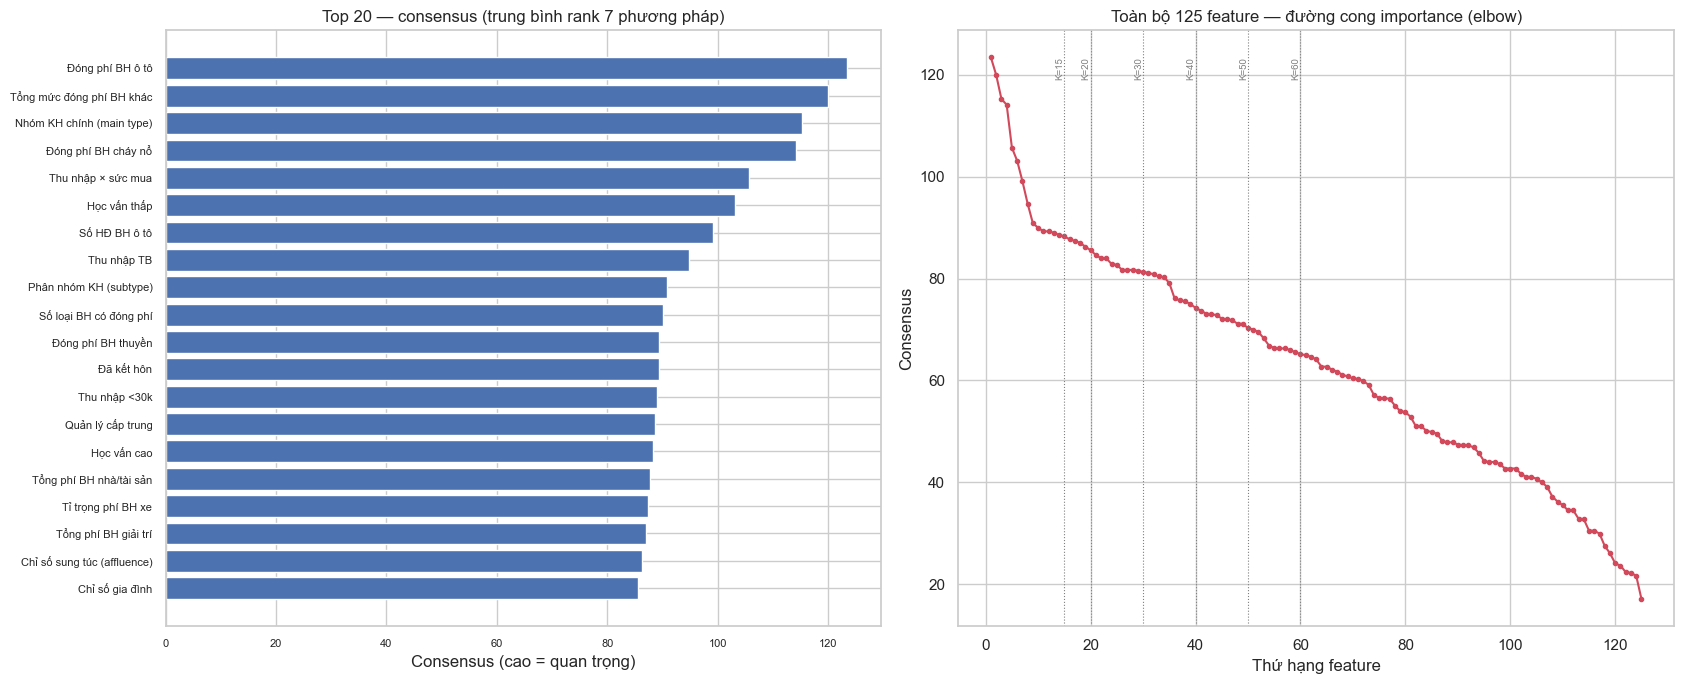

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
t = CONSENSUS["consensus"].head(20)[::-1]
axes[0].barh([disp(c) for c in t.index], t.values, color="#4c72b0")
axes[0].set_title("Top 20 — consensus (trung bình rank 7 phương pháp)")
axes[0].set_xlabel("Consensus (cao = quan trọng)"); axes[0].tick_params(labelsize=8)
axes[1].plot(np.arange(1, len(CONSENSUS)+1), CONSENSUS["consensus"].values, marker="o", ms=3, color="#d1495b")
for k in [15, 20, 30, 40, 50, 60]:
    axes[1].axvline(k, color="grey", ls=":", lw=.8)
    axes[1].text(k, CONSENSUS["consensus"].max(), f"K={k}", rotation=90, va="top", ha="right", fontsize=7, color="grey")
axes[1].set_title("Toàn bộ %d feature — đường cong importance (elbow)" % len(CONSENSUS))
axes[1].set_xlabel("Thứ hạng feature"); axes[1].set_ylabel("Consensus")
plt.tight_layout(); savefig("FED05_consensus_importance"); plt.show()

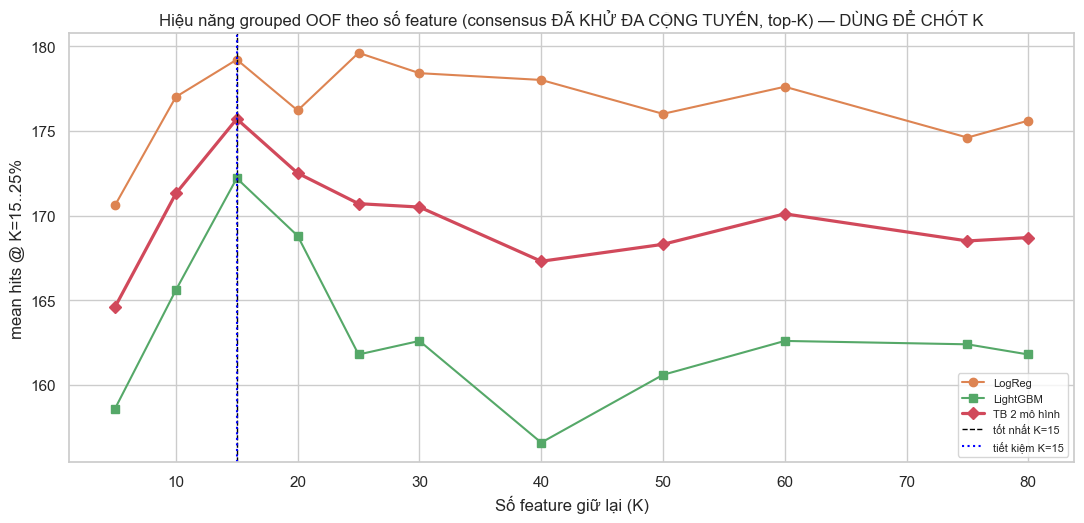

 K  meanK_LogReg  meanK_LightGBM  meanK_avg  hits_LGB
 5         170.6           158.6      164.6       159
10         177.0           165.6      171.3       173
15         179.2           172.2      175.7       171
20         176.2           168.8      172.5       174
25         179.6           161.8      170.7       159
30         178.4           162.6      170.5       163
40         178.0           156.6      167.3       155
50         176.0           160.6      168.3       160
60         177.6           162.6      170.1       162
75         174.6           162.4      168.5       164
80         175.6           161.8      168.7       163

>> Tốt nhất: K=15 (meanK_avg=175.7). Tiết kiệm (≈ tốt nhất, ít feature hơn): K=15.
=> Xem outputs/feature_importance_full_dedup.csv để tự chọn, rồi báo K muốn chốt.


In [13]:
# Hiệu năng grouped OOF theo SỐ FEATURE giữ lại (consensus ĐÃ DEDUPE, top-K) -> để CHỐT số lượng
Ks = sorted({k for k in [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90, 110, len(CONS_ORDER)] if k <= len(CONS_ORDER)})
rows = []
for K in Ks:
    d = eval_set(CONS_ORDER[:K])
    rows.append({"K": K, "meanK_LogReg": d.loc["LogReg","meanK"], "meanK_LightGBM": d.loc["LightGBM","meanK"],
                 "meanK_avg": float(d["meanK"].mean()), "hits_LGB": int(d.loc["LightGBM","hits@20%"])})
perfK = pd.DataFrame(rows)
perfK.to_csv("outputs/perf_vs_K_dedup.csv", index=False, encoding="utf-8-sig")
best = perfK.loc[perfK["meanK_avg"].idxmax()]
parsi = int(perfK[perfK["meanK_avg"] >= best["meanK_avg"] - 1.0]["K"].min())   # K nhỏ nhất ~ tốt nhất

fig, ax = plt.subplots(figsize=(11, 5.4))
ax.plot(perfK["K"], perfK["meanK_LogReg"], marker="o", label="LogReg", color="#dd8452")
ax.plot(perfK["K"], perfK["meanK_LightGBM"], marker="s", label="LightGBM", color="#55a868")
ax.plot(perfK["K"], perfK["meanK_avg"], marker="D", lw=2.3, label="TB 2 mô hình", color="#d1495b")
ax.axvline(best["K"], color="black", ls="--", lw=1, label=f"tốt nhất K={int(best['K'])}")
ax.axvline(parsi, color="blue", ls=":", lw=1.5, label=f"tiết kiệm K={parsi}")
ax.set_title("Hiệu năng grouped OOF theo số feature (consensus ĐÃ KHỬ ĐA CỘNG TUYẾN, top-K) — DÙNG ĐỂ CHỐT K")
ax.set_xlabel("Số feature giữ lại (K)"); ax.set_ylabel("mean hits @ K=15..25%"); ax.legend(fontsize=8)
plt.tight_layout(); savefig("FED08_perf_vs_K"); plt.show()
print(perfK.round(1).to_string(index=False))
print(f"\n>> Tốt nhất: K={int(best['K'])} (meanK_avg={best['meanK_avg']:.1f}). "
      f"Tiết kiệm (≈ tốt nhất, ít feature hơn): K={parsi}.")
print("=> Xem outputs/feature_importance_full_dedup.csv để tự chọn, rồi báo K muốn chốt.")

## 7. Chọn lọc đặc trưng + validate (grouped OOF, 2 mô hình)

Bộ ứng viên: full v2, after-VIF, consensus top-K (quét), RFECV (grouped), L1-selected, stability core. Chấm bằng harness. **Quy tắc chọn**: max `meanK(2 mô hình)`; hoà → ít cột hơn; rồi AUC.

In [14]:
cand = {"full v2": FULL, "after corr-cluster": AFTER_MC, "after VIF": AFTER_VIF}
for k in [20, 30, 40, 50]:
    cand[f"consensus top{k}"] = CONS_ORDER[:k]

# RFECV (grouped) với LogisticRegression (nhanh)
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
rfe_est = Pipeline([("sc", StandardScaler()),
                    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))])
# RFECV cần importance_getter; dùng coef của bước lr
from sklearn.feature_selection import RFECV
rfecv = RFECV(LogisticRegression(max_iter=2000, class_weight="balanced"), step=5,
              cv=StratifiedGroupKFold(5, shuffle=True, random_state=SEED), scoring="roc_auc",
              min_features_to_select=15, n_jobs=1, importance_getter="coef_")
rfecv.fit(StandardScaler().fit_transform(Xenc), y, groups=GROUPS)
RFE_SEL = [names[i] for i in range(len(names)) if rfecv.support_[i]]
cand["RFECV (grouped)"] = RFE_SEL
print(f"RFECV chọn {len(RFE_SEL)} cột")

# L1-selected
L1_SEL = [names[i] for i in range(len(names)) if abs(l1.coef_[0][i]) > 1e-6]
cand["L1-selected"] = L1_SEL

# Stability selection: L1 trên nhiều subsample -> tần suất chọn
rng = np.random.RandomState(SEED); freq = np.zeros(len(names))
for _ in range(20):
    idx = rng.choice(len(y), int(0.7*len(y)), replace=False)
    m = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, class_weight="balanced", max_iter=2000)
    m.fit(StandardScaler().fit_transform(Xenc[idx]), y.iloc[idx])
    freq += (np.abs(m.coef_[0]) > 1e-6)
freq /= 20
STAB = [names[i] for i in range(len(names)) if freq[i] >= 0.6]
cand["stability core (>=0.6)"] = STAB
print(f"Stability core: {len(STAB)} cột")

RFECV chọn 30 cột


Stability core: 60 cột


In [15]:
# Chấm toàn bộ bộ ứng viên
rows = []
for nm, cs in cand.items():
    if len(cs) < 5:
        continue
    mK, hL, auc = eval_compact(cs)
    rows.append({"bộ": nm, "n_cột": len(cs), "meanK(2mdl)": round(mK,1), "hits_LGB": hL, "AUC": round(auc,4)})
sel = pd.DataFrame(rows)
# Quy tắc chọn: max meanK -> ít cột -> AUC
sel = sel.sort_values(["meanK(2mdl)", "n_cột", "AUC"], ascending=[False, True, False]).reset_index(drop=True)
print(sel.to_string(index=False))
FINAL_NAME = sel.iloc[0]["bộ"]; FINAL_FEATURES = cand[FINAL_NAME]
print(f"\n=> CHỌN: {FINAL_NAME}  ({len(FINAL_FEATURES)} cột)")

                    bộ  n_cột  meanK(2mdl)  hits_LGB    AUC
stability core (>=0.6)     60        175.9       173 0.7606
           L1-selected     72        172.6       164 0.7540
       consensus top20     20        172.5       174 0.7559
               full v2    125        170.9       164 0.7510
       consensus top30     30        170.5       163 0.7561
    after corr-cluster     80        169.2       161 0.7498
       consensus top50     50        168.3       160 0.7537
       RFECV (grouped)     30        167.9       146 0.7459
       consensus top40     40        167.3       155 0.7538
             after VIF     78        165.6       156 0.7494

=> CHỌN: stability core (>=0.6)  (60 cột)


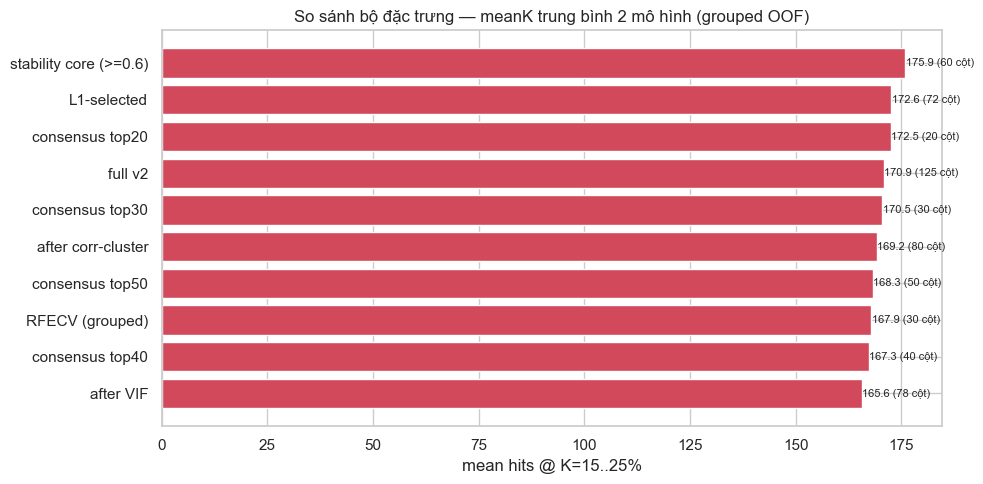

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
s = sel.sort_values("meanK(2mdl)")
ax.barh(s["bộ"], s["meanK(2mdl)"], color="#d1495b")
ax.set_title("So sánh bộ đặc trưng — meanK trung bình 2 mô hình (grouped OOF)")
ax.set_xlabel("mean hits @ K=15..25%")
for i, (v, n_) in enumerate(zip(s["meanK(2mdl)"], s["n_cột"])):
    ax.text(v+0.1, i, f"{v:.1f} ({n_} cột)", va="center", fontsize=8)
plt.tight_layout(); savefig("FED06_selection_compare"); plt.show()

## 8. Kiểm định leakage & drift train↔test

In [17]:
# (a) Không leakage: đặc trưng v2 row-wise; encoder target chỉ trong pipeline -> khẳng định bằng so khớp
chk = build_features_v2(train, test)[0]  # build lại độc lập
ok_rowwise = np.allclose(chk[ENG].values, Xtr[ENG].values, equal_nan=True)
# (b) Drift: PSI cho đặc trưng mới
def psi(exp, act, bins=10):
    qs = np.unique(np.quantile(exp, np.linspace(0, 1, bins+1)))
    if len(qs) < 3: return 0.0
    e = np.histogram(exp, qs)[0]/len(exp) + 1e-6
    a = np.histogram(act, qs)[0]/len(act) + 1e-6
    return float(np.sum((a-e)*np.log(a/e)))
drift = pd.Series({c: psi(Xtr[c].values, Xte[c].values) for c in ENG}).sort_values(ascending=False)
print("Đặc trưng v2 PSI cao nhất (train vs test):")
print(drift.head(8).rename(index=lambda c: disp(c)).round(4).to_string())
print(f"\nĐặc trưng row-wise tái lập khớp: {ok_rowwise}")
print(f"Test có đủ FINAL_FEATURES: {set(FINAL_FEATURES).issubset(Xte.columns)} | NaN test: {int(Xte[FINAL_FEATURES].isna().sum().sum())}")
print(f"PSI max = {drift.max():.4f} ( <0.1 = ổn định, 0.1-0.25 = nhẹ, >0.25 = lệch )")

Đặc trưng v2 PSI cao nhất (train vs test):
Chỉ số học vấn                        0.0052
Thu nhập × sức mua                    0.0052
Tuổi × nhóm KH chính                  0.0039
Tần suất Phân nhóm KH (subtype)       0.0039
Chỉ số mức thu nhập                   0.0038
Tần suất Nhóm KH chính (main type)    0.0035
Chỉ số sung túc (affluence)           0.0035
Chỉ số gia đình                       0.0034

Đặc trưng row-wise tái lập khớp: True
Test có đủ FINAL_FEATURES: True | NaN test: 0
PSI max = 0.0052 ( <0.1 = ổn định, 0.1-0.25 = nhẹ, >0.25 = lệch )


## 9. Bàn giao artifact (feature_set_dedup.json + parquet)

In [18]:
feature_set = {
    "raw": RAW, "all_engineered": ENG, "full_v2": FULL,
    "after_multicollinearity": AFTER_VIF,
    "consensus_rank": CONS_ORDER,
    "final_selected": list(FINAL_FEATURES),
    "final_name": FINAL_NAME,
}
with open("outputs/feature_set_dedup.json", "w", encoding="utf-8") as f:
    json.dump(feature_set, f, ensure_ascii=False, indent=2)

keep_cols = ["ID"] + FINAL_FEATURES
Xtr_out = Xtr[keep_cols].copy(); Xtr_out[TARGET] = y.values
Xte_out = Xte[keep_cols].copy()
try:
    Xtr_out.to_parquet("outputs/train_fe_dedup.parquet"); Xte_out.to_parquet("outputs/test_fe_dedup.parquet")
    fmt = "parquet"
except Exception as e:
    Xtr_out.to_csv("outputs/train_fe_dedup.csv", index=False); Xte_out.to_csv("outputs/test_fe_dedup.csv", index=False); fmt = "csv"
print(f"Đã ghi: outputs/feature_set_dedup.json + train_fe/test_fe ({fmt})")

# verify load
from src.features import load_feature_set
ld = load_feature_set("final_selected", path="outputs/feature_set_dedup.json")
print(f"load_feature_set('final_selected') -> {len(ld)} cột | khớp: {ld == list(FINAL_FEATURES)}")
print("\nCách dùng ở training.ipynb: COLS_X = load_feature_set('final_selected'); rồi truyền vào oof_proba/build_pipeline như cũ.")

Đã ghi: outputs/feature_set_dedup.json + train_fe/test_fe (parquet)
load_feature_set('final_selected') -> 60 cột | khớp: True

Cách dùng ở training.ipynb: COLS_X = load_feature_set('final_selected'); rồi truyền vào oof_proba/build_pipeline như cũ.


## 10. Tổng kết

In [19]:
print("="*66); print("TỔNG KẾT FEATURE ENGINEERING — VPINS AIA"); print("="*66)
print(f"RAW 85 -> +{len(ENG)} đặc trưng v2 = {len(FULL)} -> khử đa cộng tuyến -> chọn {len(FINAL_FEATURES)} ('{FINAL_NAME}')")
b = eval_set(RAW); e = eval_set(RAW+ENG1); f = eval_set(FINAL_FEATURES)
comp = pd.DataFrame({
    "raw (85)": [b.loc["LogReg","meanK"], b.loc["LightGBM","meanK"]],
    "eng v1":   [e.loc["LogReg","meanK"], e.loc["LightGBM","meanK"]],
    f"FINAL ({len(FINAL_FEATURES)})": [f.loc["LogReg","meanK"], f.loc["LightGBM","meanK"]],
}, index=["LogReg meanK", "LightGBM meanK"]).round(1)
print(comp.to_string())
print(f"\nNZV (gắn cờ loại): {len(NZV_COLS)} | cụm corr>0.9 gộp: {len(FULL)-len(AFTER_MC)} | VIF loại: {len(removed_vif)}")
print("\nArtifact: outputs/feature_set_dedup.json, outputs/train_fe_dedup.parquet, test_fe_dedup.parquet")
print("Figures: figures/FED01..FED06")

TỔNG KẾT FEATURE ENGINEERING — VPINS AIA
RAW 85 -> +40 đặc trưng v2 = 125 -> khử đa cộng tuyến -> chọn 60 ('stability core (>=0.6)')


                raw (85)  eng v1  FINAL (60)
LogReg meanK       163.2   171.2       181.4
LightGBM meanK     163.2   166.8       170.4

NZV (gắn cờ loại): 20 | cụm corr>0.9 gộp: 45 | VIF loại: 2

Artifact: outputs/feature_set_dedup.json, outputs/train_fe_dedup.parquet, test_fe_dedup.parquet
Figures: figures/FED01..FED06


## 11. Feature importance — TOÀN BỘ feature (xem độ chênh)

Vẽ consensus của cả 125 feature (thanh lỗi = `rank_std` = độ bất nhất giữa 7 phương pháp), tô màu theo nhóm đặc trưng. Cell **tự chứa** (đọc `outputs/feature_importance_full_dedup.csv`) nên chạy độc lập được.

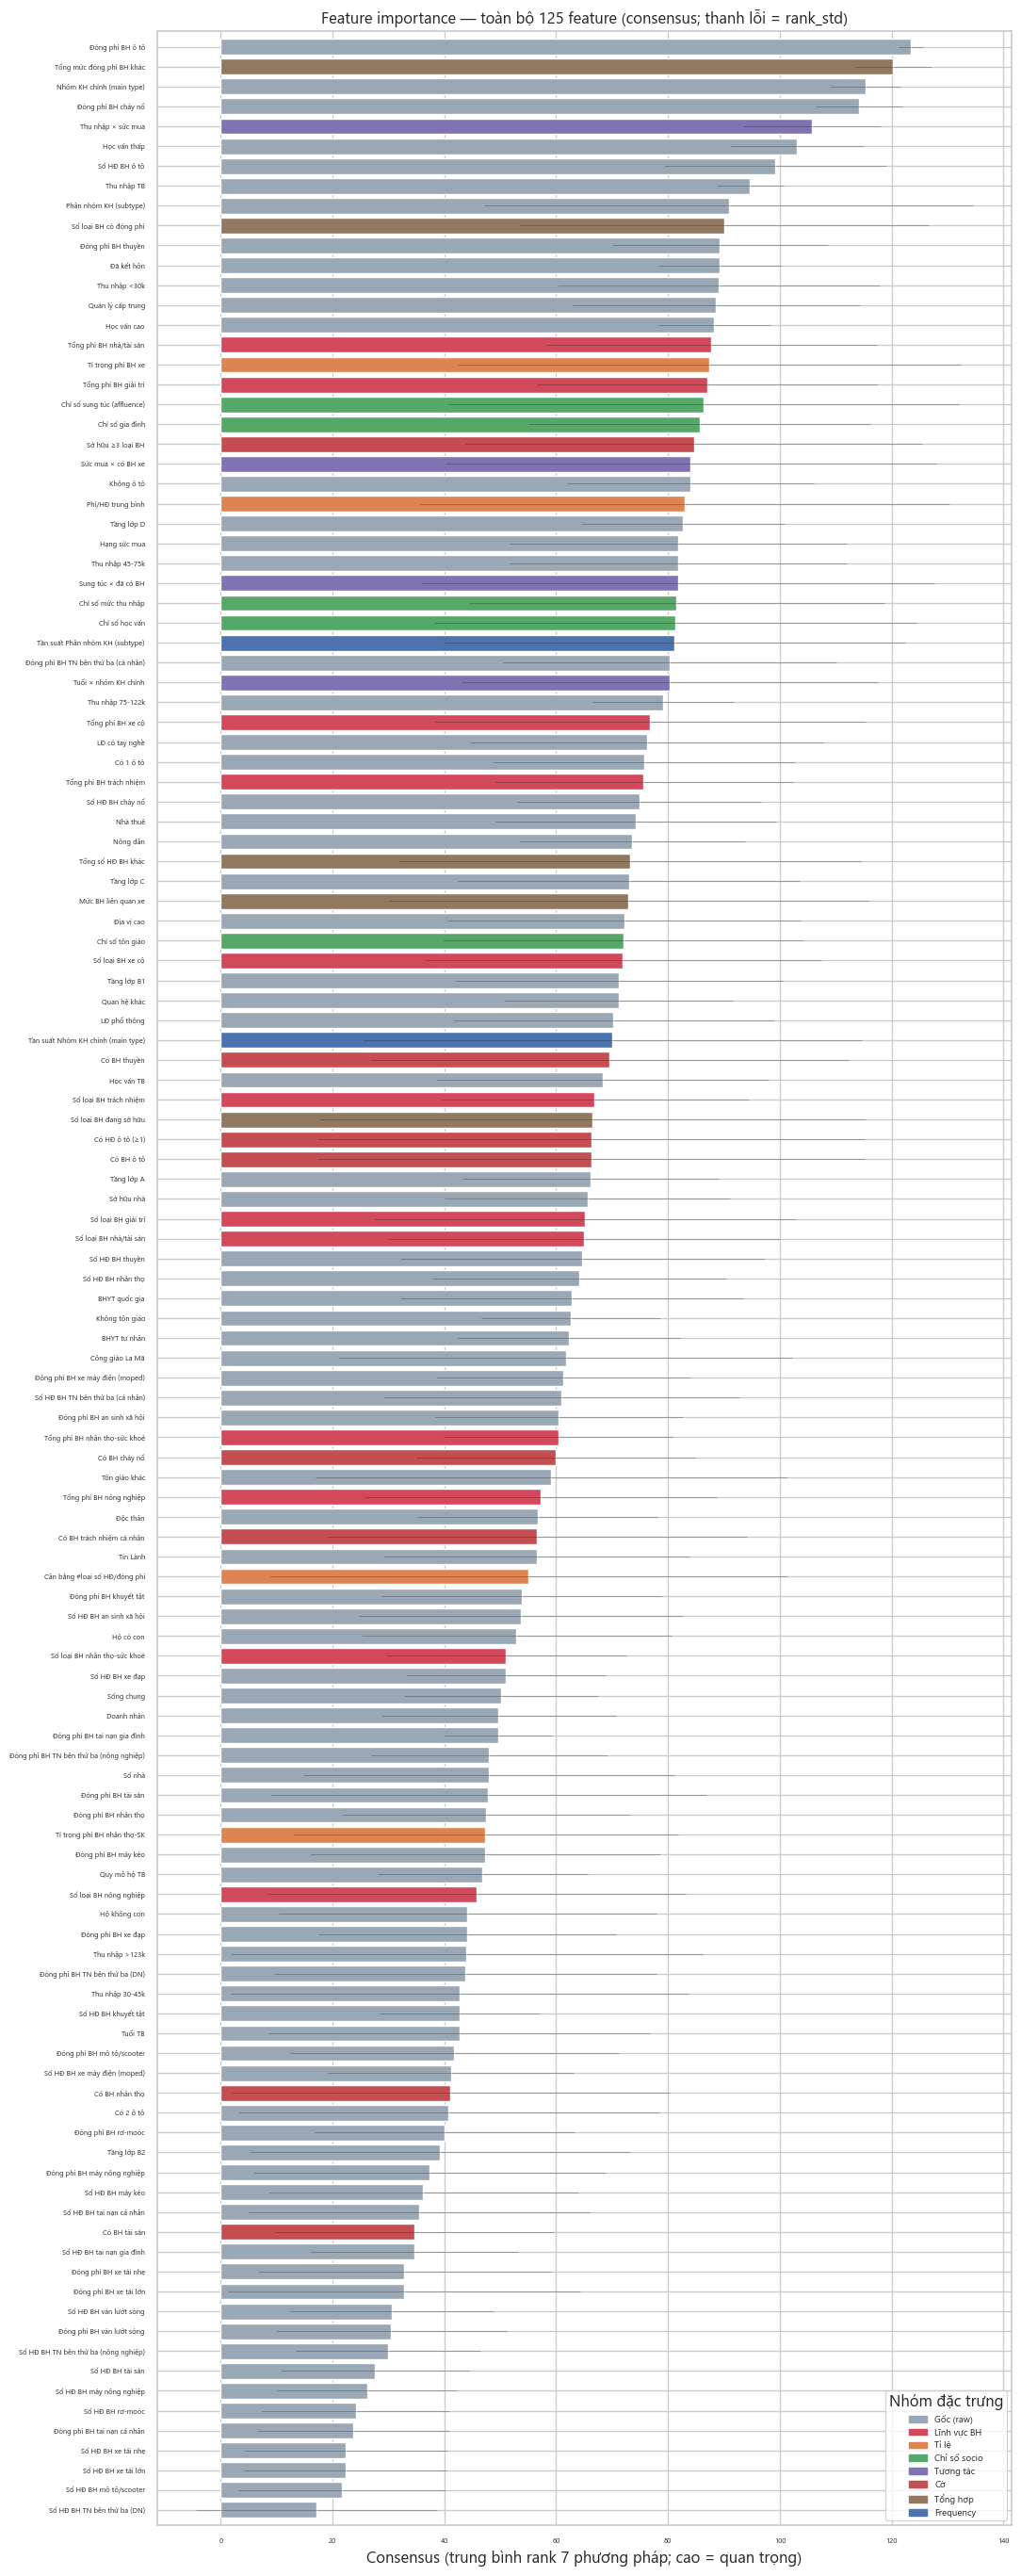

Độ chênh consensus: max=123.4, min=17.1 (chênh 106.3)
Top10 TB=105.7 vs Bottom10 TB=24.6
rank_std (bất nhất): min=2.1, max=48.9, TB=28.1


In [20]:
# Cell tự chứa: đọc outputs/feature_importance_full_dedup.csv -> vẽ full importance
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

tbl = pd.read_csv("outputs/feature_importance_full_dedup.csv"); tbl["col"] = tbl["col"].astype(str)
def _grp(c):
    for p, g in [("dom_","Lĩnh vực BH"), ("ratio_","Tỉ lệ"), ("idx_","Chỉ số socio"), ("ix_","Tương tác"),
                 ("flag_","Cờ"), ("agg_","Tổng hợp"), ("freq_","Frequency")]:
        if c.startswith(p): return g
    return "Gốc (raw)"
tbl["group"] = tbl["col"].map(_grp); tbl = tbl.sort_values("consensus")
palette = {"Gốc (raw)":"#9aa7b5", "Lĩnh vực BH":"#d1495b", "Tỉ lệ":"#dd8452", "Chỉ số socio":"#55a868",
           "Tương tác":"#8172b3", "Cờ":"#c44e52", "Tổng hợp":"#937860", "Frequency":"#4c72b0"}
colors = [palette[g] for g in tbl["group"]]

fig, ax = plt.subplots(figsize=(11, max(20, len(tbl)*0.22)))
ax.barh(tbl["feature"], tbl["consensus"], xerr=tbl["rank_std"], color=colors, error_kw=dict(alpha=.35, lw=.6))
ax.set_title(f"Feature importance — toàn bộ {len(tbl)} feature (consensus; thanh lỗi = rank_std)")
ax.set_xlabel("Consensus (trung bình rank 7 phương pháp; cao = quan trọng)")
ax.tick_params(labelsize=5.5); ax.margins(y=0.003)
handles = [mpatches.Patch(color=palette[g], label=g) for g in palette if g in set(tbl["group"])]
ax.legend(handles=handles, fontsize=7, loc="lower right", title="Nhóm đặc trưng")
plt.tight_layout(); plt.savefig("figures/FED09_all_importance.png", dpi=150, bbox_inches="tight"); plt.show()

print("Độ chênh consensus: max=%.1f, min=%.1f (chênh %.1f)" % (
    tbl.consensus.max(), tbl.consensus.min(), tbl.consensus.max()-tbl.consensus.min()))
print("Top10 TB=%.1f vs Bottom10 TB=%.1f" % (tbl.consensus.nlargest(10).mean(), tbl.consensus.nsmallest(10).mean()))
print("rank_std (bất nhất): min=%.1f, max=%.1f, TB=%.1f" % (tbl.rank_std.min(), tbl.rank_std.max(), tbl.rank_std.mean()))